In [1]:
!pwd

/content


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import cvxpy as cp
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


pc = loadmat('SVM_Approx.mat');
X = pc['X'];
Y = pc['Y'];
N = pc['N'][0,0];

# Prepare dataset
X_class1 = X[:, 0:N-1].T
X_class2 = Y[:, 0:N-1].T

X_all = np.vstack((X_class1, X_class2))

y_class1 = np.ones(X_class1.shape[0])
y_class2 = -np.ones(X_class2.shape[0])

y_all = np.hstack((y_class1, y_class2))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

C = 1   # Regularization parameter

a = cp.Variable(2)
b = cp.Variable(1)
ei = cp.Variable(len(y_train))
objective = cp.Minimize(0.5 * cp.norm(a, 2)**2 + C * cp.sum(ei))
constraints = [cp.multiply(y_train, X_train @ a + b) >= 1 - ei,ei >= 0]
prob = cp.Problem(objective, constraints)
result = prob.solve()


RNG = np.arange(-5,5,0.1);
a = a.value;
b = b.value;

def predict(X, w, b):
    return np.sign(X @ w + b)

y_pred = predict(X_test, a, b)

print("Approximate SVM Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Approximate SVM Results
Accuracy: 0.965
              precision    recall  f1-score   support

        -1.0       0.97      0.96      0.97       106
         1.0       0.96      0.97      0.96        94

    accuracy                           0.96       200
   macro avg       0.96      0.97      0.96       200
weighted avg       0.97      0.96      0.97       200



Plot-Approximate SVM

(np.float64(-6.940679103790112),
 np.float64(7.095021267744643),
 np.float64(-6.495419757041109),
 np.float64(7.428336300419465))

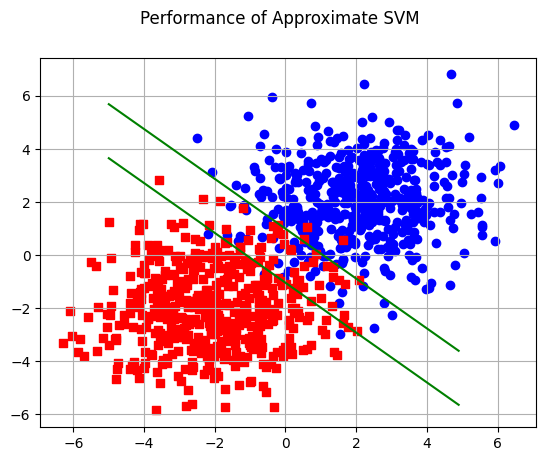

In [4]:
plt.scatter(X[0,0:N-1], X[1,0:N-1], marker="o",color="b");
plt.scatter(Y[0,0:N-1], Y[1,0:N-1], marker="s",color="r");
plt.plot(RNG, (-RNG*a[0] - b[0] + 1)/a[1], "g-")
plt.plot(RNG, (-RNG*a[0] - b[0] - 1)/a[1], "g-")
plt.grid(1,which='both')
plt.suptitle('Performance of Approximate SVM')
plt.axis('tight')